 Explained Variance Ratio: 
[0.43628873 0.12974188 0.12212732 0.11050223 0.0768238 ]

Cumulative Variance Explained Ratio: 0.88

SoVI: 
     Ward  SoVI_Score  SoVI_Normalised
109   110    7.170295         1.000000
31     32    6.737103         0.970588
39     40    5.131878         0.861599
9      10    4.945619         0.848953
41     42    4.872408         0.843982
79     80    4.783186         0.837924
44     45    4.562121         0.822915
139   140    4.459964         0.815979
138   139    4.437382         0.814445
103   104    4.412098         0.812729


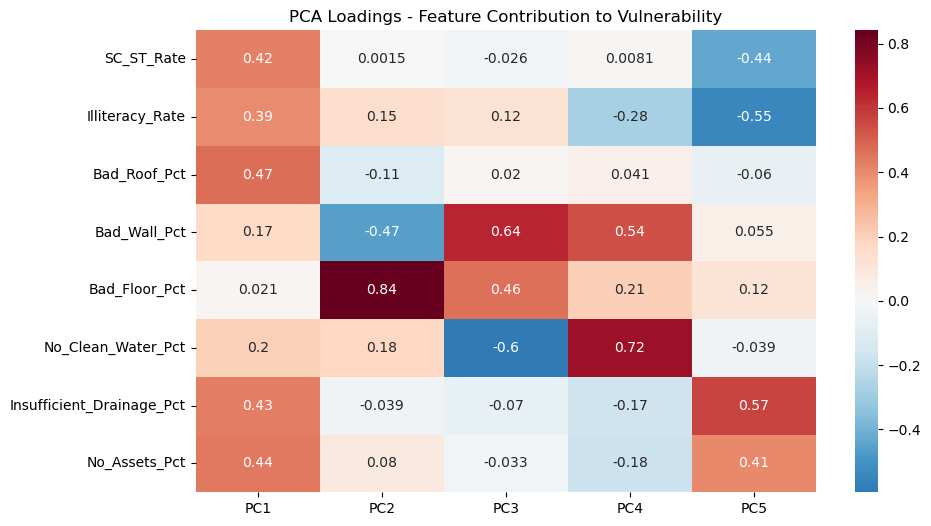

In [6]:
#PCA Calculation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1.Load Dataset
df = pd.read_csv('Chennai_SV_Clean.csv')

df['No_Clean_Water_Pct'] = 100 - df['Clean_Water_Pct']

features = [
    'SC_ST_Rate', 'Illiteracy_Rate',
    'Bad_Roof_Pct', 'Bad_Wall_Pct', 'Bad_Floor_Pct', 'No_Clean_Water_Pct', 'Insufficient_Drainage_Pct',
    'No_Assets_Pct']

X = df[features].copy()

pca_input = df[['Ward'] + features].dropna().copy()

# 2. Z-Score Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 3. Execute PCA
# We set n_components to capture at least 70-80% of the variance.
pca = PCA(n_components=0.80)
pca_data = pca.fit_transform(X_scaled)

# Get Loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca_data.shape[1])], 
    index=features
)

print(" Explained Variance Ratio: ")
print(pca.explained_variance_ratio_)
print(f"\nCumulative Variance Explained Ratio: {sum(pca.explained_variance_ratio_):.2f}")


# 4. Polarity Adjustment
# SoVI: higher score, more vulnerable

# Check the direction (polarity) of each Principal Component (PC). 
# If a PC has a positive loading on resilience indicators and a negative loading on vulnerability indicators, it essentially measures "Resilience". 
# Its sign must be inverted before aggregation to ensure a consistent vulnerability scale.
component_scores = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])], index=pca_input.index)

# SoVI Aggregation Methodology:
# We examine the directional correlation of each PC with a predefined "vulnerability anchor", aligning their signs (Polarity Adjustment) before summing them up to calculate the final index.
adjusted_pc_scores = component_scores.copy()
for col in loadings.columns:
    # If the PC is negatively correlated with the vulnerability anchor (e.g., 'Bad_Roof_Pct'), invert the sign of this entire component vector.
    if loadings.loc['Bad_Roof_Pct', col] < 0:
        adjusted_pc_scores[col] = -adjusted_pc_scores[col]


# 5. Final Score Computation
pca_input['SoVI_Score'] = adjusted_pc_scores.sum(axis=1)

sovi_min = pca_input['SoVI_Score'].min()
sovi_max = pca_input['SoVI_Score'].max()

if sovi_max > sovi_min:
    pca_input['SoVI_Normalised'] = (
        (pca_input['SoVI_Score'] - sovi_min) / (sovi_max - sovi_min)
    )
else:
    pca_input['SoVI_Normalised'] = 0

df = df.merge(
    pca_input[['Ward', 'SoVI_Score', 'SoVI_Normalised']],
    on='Ward',
    how='left'
)


# 6. Export & Visualization
df.to_csv('Chennai_SoVI_Results.csv', index=False)

# Heatmap for Interpretation
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0)
plt.title('PCA Loadings - Feature Contribution to Vulnerability')
plt.savefig('PCA_Loadings_Heatmap.png')

print("\nSoVI: ")
print(df[['Ward', 'SoVI_Score', 'SoVI_Normalised']].sort_values('SoVI_Score', ascending=False).head(10))

In [7]:
# The most vulerable areas in Chennai Top 10
vulnerable_top10 = df[['Ward', 'SoVI_Score', 'SoVI_Normalised']].sort_values('SoVI_Normalised', ascending=False)
print("The most vulerable areas in Chennai Top 10: ")
print(vulnerable_top10.head(10))

The most vulerable areas in Chennai Top 10: 
     Ward  SoVI_Score  SoVI_Normalised
109   110    7.170295         1.000000
31     32    6.737103         0.970588
39     40    5.131878         0.861599
9      10    4.945619         0.848953
41     42    4.872408         0.843982
79     80    4.783186         0.837924
44     45    4.562121         0.822915
139   140    4.459964         0.815979
138   139    4.437382         0.814445
103   104    4.412098         0.812729


In [ ]:
# Risk score = UHI * SoVI * population density
# This cell is for: SoVI * population density
df['SoVI_x_PopDensity'] = df['SoVI_Normalised'] * df['Pop_Density_Norm']

risk_min = df['SoVI_x_PopDensity'].min()
risk_max = df['SoVI_x_PopDensity'].max()

if risk_max > risk_min:
    df['SoVI_x_PopDensity_Norm'] = (
        (df['SoVI_x_PopDensity'] - risk_min) / (risk_max - risk_min)
    )
else:
    df['SoVI_x_PopDensity_Norm'] = 0

df.to_csv('Chennai_SoVI_x_popdensitynorm.csv', index=False)

print("\nTop 10 wards by SoVI × Population Density:")
print(
    df[['Ward', 'SoVI_Normalised', 'Pop_Density_Norm', 'SoVI_x_PopDensity', 'SoVI_x_PopDensity_Norm']]
    .sort_values('SoVI_x_PopDensity', ascending=False)
    .head(10)
)


Top 10 wards by SoVI × Population Density:
     Ward  SoVI_Normalised  Pop_Density_Norm  SoVI_x_PopDensity  \
41     42         0.843982          0.969477           0.818221   
9      10         0.848953          0.787018           0.668141   
129   130         0.784694          0.808022           0.634050   
31     32         0.970588          0.647980           0.628921   
11     12         0.635840          0.914202           0.581286   
135   136         0.748251          0.753007           0.563439   
10     11         0.791149          0.708240           0.560324   
40     41         0.670872          0.824489           0.553126   
132   133         0.716643          0.716655           0.513585   
20     21         0.537037          0.949676           0.510011   

     SoVI_x_PopDensity_Norm  
41                 1.000000  
9                  0.816578  
129                0.774913  
31                 0.768645  
11                 0.710427  
135                0.688614  
10      

In [8]:
%pip install factor_analyzer

Note: you may need to restart the kernel to use updated packages.


Bartlett's Test: 
Chi-Square: 445.33
P-value: 0.00000
P-value < 0.05: Variables are correlated. PCA is appropriate.

KMO Measure: 
Overall KMO Score: 0.777
KMO > 0.6: Sampling adequacy is acceptable for PCA.


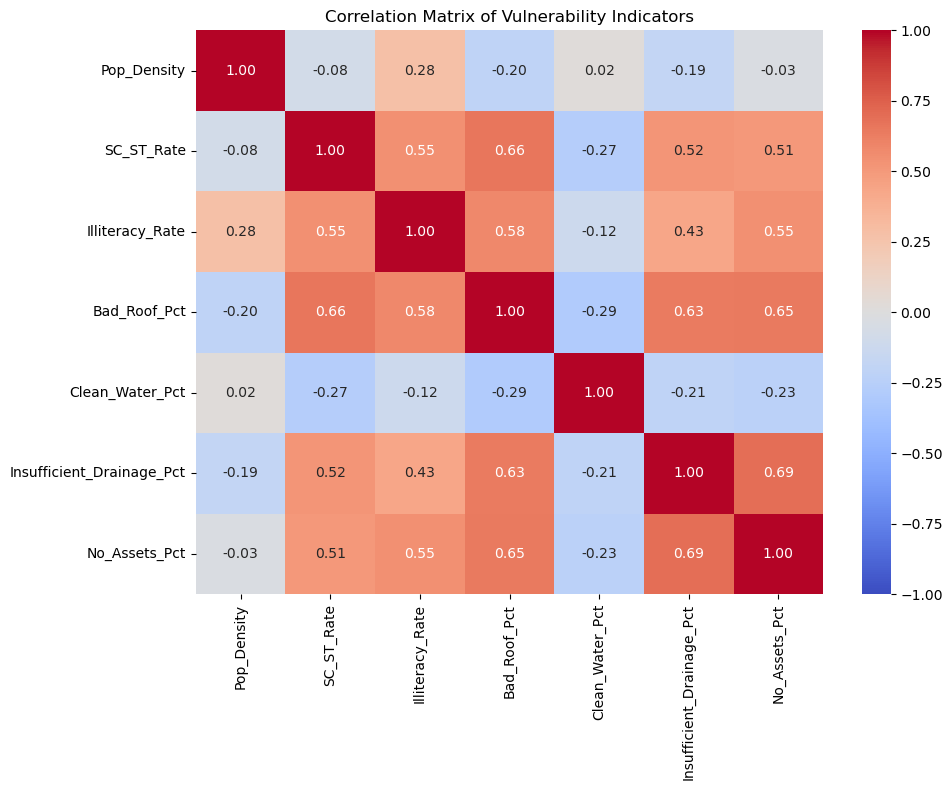

In [10]:
# check for underlying multicollinearity
import pandas as pd
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

# 1. Load Dataset
df_clean = pd.read_csv('Chennai_SV_Clean.csv').copy()

features = [
    'Pop_Density', 'SC_ST_Rate', 'Illiteracy_Rate', 
    'Bad_Roof_Pct', 'Clean_Water_Pct', 'Insufficient_Drainage_Pct', 
    'No_Assets_Pct']
X = df_clean[features]

# 2. Bartlett's Test of Sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(X)

print("Bartlett's Test: ")
print(f"Chi-Square: {chi_square_value:.2f}")
print(f"P-value: {p_value:.5f}")
if p_value < 0.05:
    print("P-value < 0.05: Variables are correlated. PCA is appropriate.")
else:
    print("P-value >= 0.05: Variables are orthogonal. PCA may not be useful.")


# 3. KMO Measure (Kaiser-Meyer-Olkin)
kmo_all, kmo_model = calculate_kmo(X)

print("\nKMO Measure: ")
print(f"Overall KMO Score: {kmo_model:.3f}")
if kmo_model > 0.6:
    print("KMO > 0.6: Sampling adequacy is acceptable for PCA.")
else:
    print("KMO < 0.6: Sampling adequacy is low. Consider dropping isolated variables.")
    

# 4. Correlation Matrix Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Vulnerability Indicators')
plt.tight_layout()
plt.show()